## 1. Import Required Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

Keep your dataset file name as **dataset.csv** and place it in the same folder as this notebook.

The target column should be named **Credit_Score**.

Example target values:
- Good
- Standard
- Poor


In [9]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("dataset.csv")
df.head()

Saving dataset.csv to dataset (2).csv


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Monthly_Balance,Credit_Score
0,61,34592,1933,6,5,9.90,1,47,3,71482,12.82,14,1041,4905,Poor
1,26,48657,3530,5,1,16.22,5,41,13,28893,45.43,9,26523,1851,Poor
2,31,111506,9157,3,5,8.11,2,6,2,49797,13.70,28,11270,80131,Good
3,37,125791,9570,6,8,15.72,3,5,9,47400,56.96,23,2279,7006,Standard
4,63,49871,4738,3,2,22.11,0,24,8,59429,62.21,12,5329,49520,Poor


## 3. Basic Dataset Information

In [10]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

Dataset Shape: (2000, 15)

Column Names:
['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Monthly_Balance', 'Credit_Score']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2000 non-null   int64  
 1   Annual_Income             2000 non-null   int64  
 2   Monthly_Inhand_Salary     2000 non-null   int64  
 3   Num_Bank_Accounts         2000 non-null   int64  
 4   Num_Credit_Card           2000 non-null   int64  
 5   Interest_Rate             2000 non-null   float64
 6   Num_of_Loan               2000 non-null   int64  
 7   Delay_from_due_date       2000 non-nul

In [11]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Age                         0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Total_EMI_per_month         0
Monthly_Balance             0
Credit_Score                0
dtype: int64


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 4. Data Cleaning

In [13]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing values
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].median())

print("Data cleaning completed.")
print("New shape:", df.shape)

Data cleaning completed.
New shape: (2000, 15)


## 5. Target Column Check

In [14]:
target_column = "Credit_Score"

if target_column not in df.columns:
    raise ValueError("Target column 'Credit_Score' not found. Please check your dataset column name.")

print(df[target_column].value_counts())

Credit_Score
Poor        1292
Standard     628
Good          80
Name: count, dtype: int64


## 6. Exploratory Data Analysis

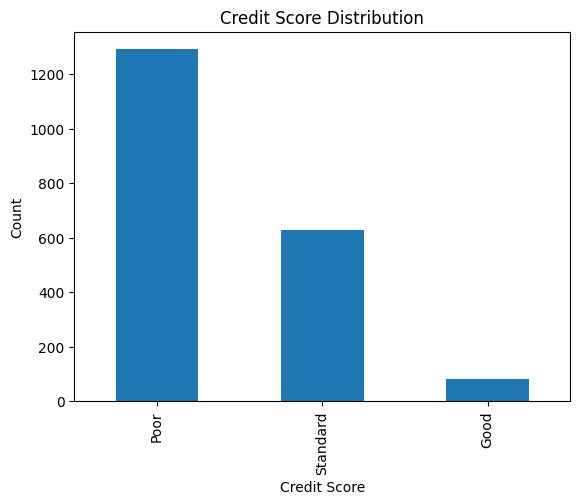

In [15]:
# Target distribution
df[target_column].value_counts().plot(kind="bar")
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.show()

In [16]:
# Numerical feature summary
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Monthly_Balance
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,42.86150,84697.788500,7047.367500,3.562000,4.529500,15.053980,2.49600,30.275500,7.472000,39928.004000,50.307445,15.280500,14894.382000,49306.785000
std,12.78601,37755.275464,3186.138046,1.716866,2.291453,5.762643,1.71565,17.912873,4.650595,22944.549298,25.516893,8.620265,8569.410019,28684.244897
min,21.00000,20071.000000,764.000000,1.000000,1.000000,5.010000,0.00000,0.000000,0.000000,12.000000,5.050000,1.000000,8.000000,1044.000000
25%,32.00000,51435.750000,4324.750000,2.000000,3.000000,10.012500,1.00000,15.000000,3.000000,19795.500000,28.095000,8.000000,7396.500000,23971.000000
50%,42.00000,84697.000000,6985.000000,4.000000,4.000000,14.975000,2.00000,30.500000,7.000000,40327.500000,51.235000,15.000000,14802.500000,49328.500000
75%,54.00000,117162.750000,9735.250000,5.000000,7.000000,20.142500,4.00000,46.000000,12.000000,59468.250000,71.880000,23.000000,22137.000000,74236.500000
max,65.00000,149980.000000,13255.000000,6.000000,8.000000,25.000000,5.00000,60.000000,15.000000,79783.000000,94.820000,30.000000,29965.000000,99938.000000


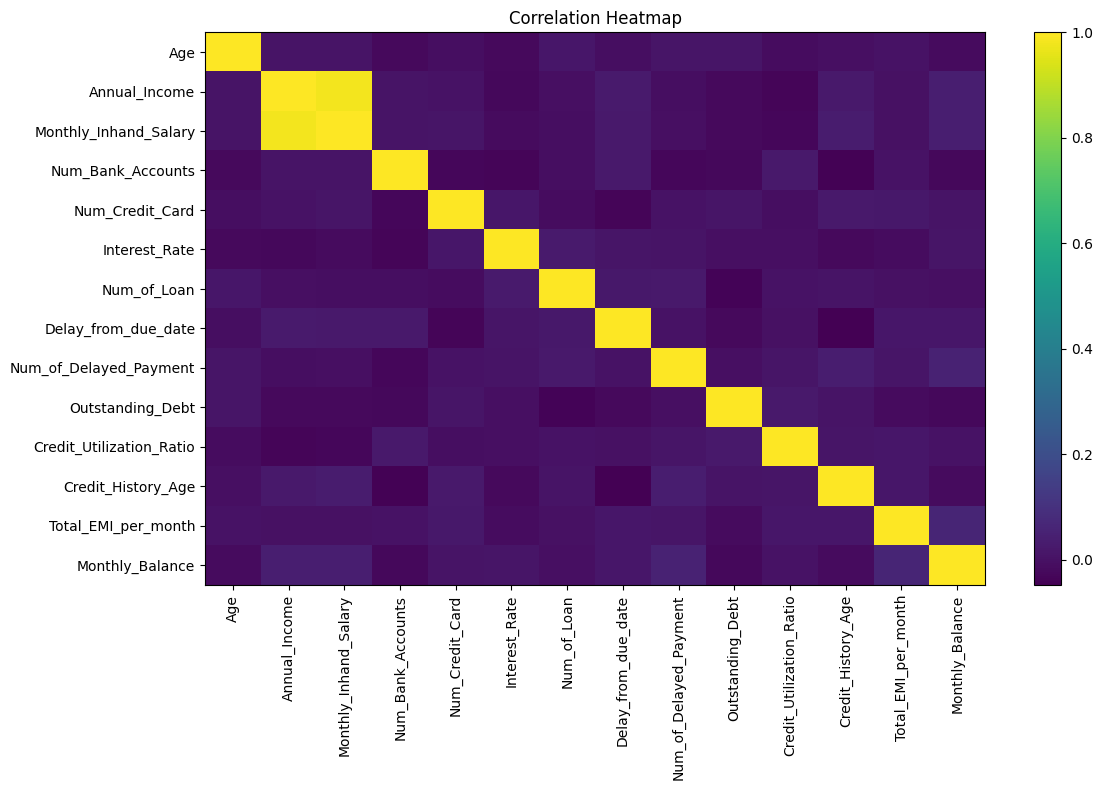

In [17]:
# Correlation heatmap using matplotlib
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] > 1:
    corr = numeric_df.corr()
    plt.figure(figsize=(12, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for correlation heatmap.")

## 7. Encode Categorical Columns

In [18]:
# Create a copy for processing
data = df.copy()

label_encoders = {}

for column in data.columns:
    if data[column].dtype == "object":
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le

data.head()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Monthly_Balance,Credit_Score
0,61,34592,1933,6,5,9.90,1,47,3,71482,12.82,14,1041,4905,1
1,26,48657,3530,5,1,16.22,5,41,13,28893,45.43,9,26523,1851,1
2,31,111506,9157,3,5,8.11,2,6,2,49797,13.70,28,11270,80131,0
3,37,125791,9570,6,8,15.72,3,5,9,47400,56.96,23,2279,7006,2
4,63,49871,4738,3,2,22.11,0,24,8,59429,62.21,12,5329,49520,1


## 8. Split Features and Target

In [19]:
X = data.drop(target_column, axis=1)
y = data[target_column]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2000, 14)
Target shape: (2000,)


## 9. Train-Test Split and Feature Scaling

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1600
Testing samples: 400


## 10. Train Machine Learning Models

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []

for model_name, model in models.items():
    if model_name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8175,0.815563,0.8175,0.816376
1,Decision Tree,0.9950,0.995010,0.9950,0.994962
2,Random Forest,0.9525,0.954785,0.9525,0.949959


## 11. Compare Model Accuracy

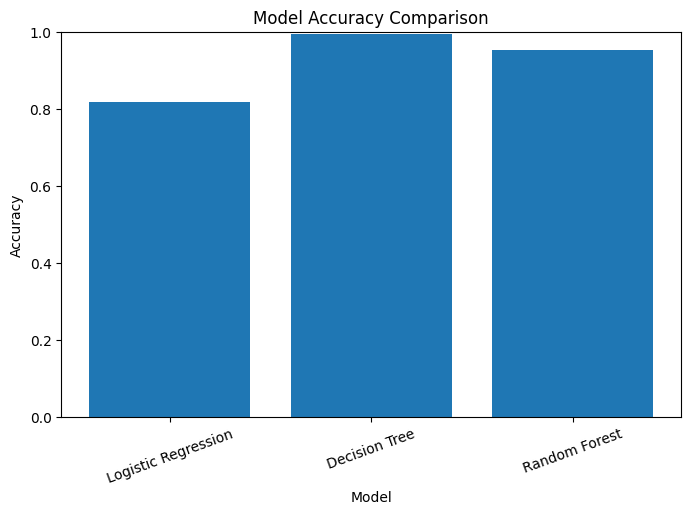

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

## 12. Select Best Model

In [23]:
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

if best_model_name == "Logistic Regression":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

Best Model: Decision Tree


## 13. Classification Report

In [24]:
print("Classification Report:")
print(classification_report(y_test, y_pred_best))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       1.00      1.00      1.00       258
           2       0.99      0.99      0.99       126

    accuracy                           0.99       400
   macro avg       1.00      0.98      0.99       400
weighted avg       1.00      0.99      0.99       400



## 14. Confusion Matrix

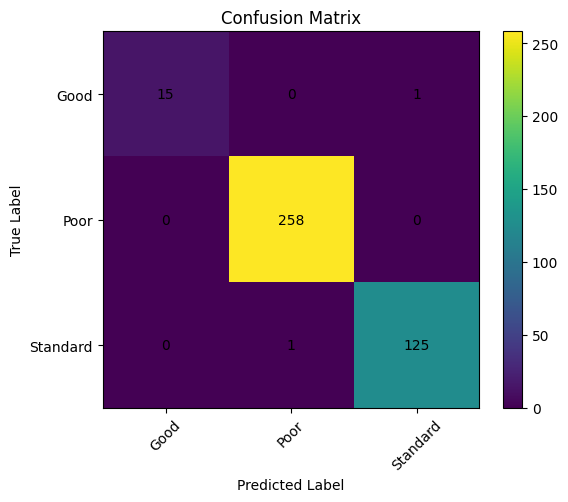

In [25]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

classes = label_encoders[target_column].classes_ if target_column in label_encoders else np.unique(y)
plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## 15. ROC-AUC Score

For multi-class classification, ROC-AUC is calculated using One-vs-Rest method.


In [26]:
try:
    if hasattr(best_model, "predict_proba"):
        if best_model_name == "Logistic Regression":
            y_score = best_model.predict_proba(X_test_scaled)
        else:
            y_score = best_model.predict_proba(X_test)

        y_test_bin = label_binarize(y_test, classes=np.unique(y))
        roc_auc = roc_auc_score(y_test_bin, y_score, multi_class="ovr")
        print("ROC-AUC Score:", roc_auc)
    else:
        print("Best model does not support probability prediction.")
except Exception as e:
    print("ROC-AUC could not be calculated:", e)

ROC-AUC Score: 0.9864786005843115


## 16. Feature Importance

Feature importance is shown for tree-based models.


                     Feature  Importance
1              Annual_Income    0.236114
9           Outstanding_Debt    0.205386
10  Credit_Utilization_Ratio    0.176269
7        Delay_from_due_date    0.170384
6                Num_of_Loan    0.135255
11        Credit_History_Age    0.070049
2      Monthly_Inhand_Salary    0.004089
13           Monthly_Balance    0.002455
3          Num_Bank_Accounts    0.000000
0                        Age    0.000000
5              Interest_Rate    0.000000
4            Num_Credit_Card    0.000000
8     Num_of_Delayed_Payment    0.000000
12       Total_EMI_per_month    0.000000


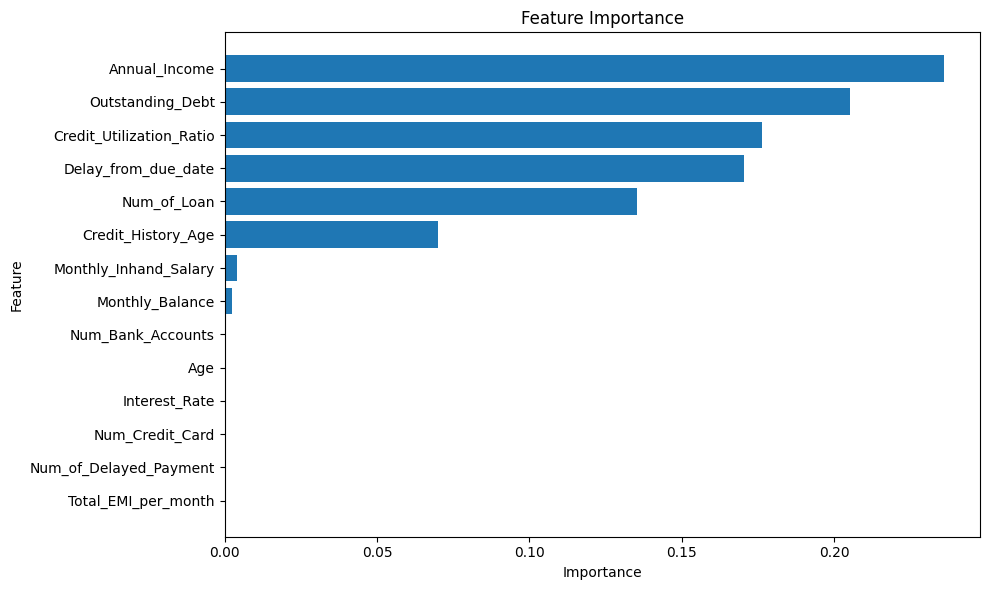

In [27]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print(importance_df)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.title("Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is not available for this model.")

## 17. Save Best Model

In [28]:
os.makedirs("models", exist_ok=True)

model_file = "models/credit_scoring_model.pkl"
scaler_file = "models/scaler.pkl"
encoder_file = "models/label_encoders.pkl"

joblib.dump(best_model, model_file)
joblib.dump(scaler, scaler_file)
joblib.dump(label_encoders, encoder_file)

print("Best model saved successfully.")
print("Model file:", model_file)
print("Scaler file:", scaler_file)
print("Encoder file:", encoder_file)

Best model saved successfully.
Model file: models/credit_scoring_model.pkl
Scaler file: models/scaler.pkl
Encoder file: models/label_encoders.pkl


## 18. Test Prediction with One Sample

In [29]:
sample = X_test.iloc[0:1]

if best_model_name == "Logistic Regression":
    sample_scaled = scaler.transform(sample)
    prediction = best_model.predict(sample_scaled)
else:
    prediction = best_model.predict(sample)

if target_column in label_encoders:
    predicted_class = label_encoders[target_column].inverse_transform(prediction)
    print("Predicted Credit Score:", predicted_class[0])
else:
    print("Predicted Credit Score:", prediction[0])

Predicted Credit Score: Poor


## 19. Conclusion

In this project, a Credit Scoring Model was developed using machine learning classification algorithms.  
The dataset was cleaned, preprocessed, encoded, and split into training and testing sets.  
Multiple models were trained and compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

The best-performing model was saved for future use.
